# Initial exploratory data analysis

---

# Setup

In [136]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pycld2 as cld2
import re
from collections import Counter
from nltk.tokenize import sent_tokenize
from nltk.util import ngrams

Import WELFake dataset, where 0 = fake and 1 = real.

In [137]:
df_raw = pd.read_csv("../../data/external/welfake/WELFake_Dataset.csv", index_col = 0)

---

# Dataset structure

In [138]:
print(df_raw.shape)

(72134, 3)


In [139]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72134 entries, 0 to 72133
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   71576 non-null  object
 1   text    72095 non-null  object
 2   label   72134 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.2+ MB


In [140]:
df_raw.head(20)

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1
6,DR BEN CARSON TARGETED BY THE IRS: “I never ha...,DR. BEN CARSON TELLS THE STORY OF WHAT HAPPENE...,1
7,HOUSE INTEL CHAIR On Trump-Russia Fake Story: ...,,1
8,Sports Bar Owner Bans NFL Games…Will Show Only...,"The owner of the Ringling Bar, located south o...",1
9,Latest Pipeline Leak Underscores Dangers Of Da...,"FILE – In this Sept. 15, 2005 file photo, the ...",1


In [141]:
print(f"Numbers of missing values\n----------------------\n{df_raw.isna().sum()}")
print(f"Proportions of missing values\n----------------------\n{df_raw.isna().mean()}")

Numbers of missing values
----------------------
title    558
text      39
label      0
dtype: int64
Proportions of missing values
----------------------
title    0.007736
text     0.000541
label    0.000000
dtype: float64


In [142]:
print(f"{df_raw.duplicated().sum()} duplicate rows")
print(f"{df_raw.duplicated(subset = ["text"]).sum()} articles with identical text")

8456 duplicate rows
9415 articles with identical text


## Initial cleaning

In [143]:
df = df_raw.copy()

Drop duplicate and missing values.

In [144]:
df.drop_duplicates(subset = ["text"], inplace = True)
df = df.replace(r'^\s*$', pd.NA, regex = True)
df.dropna(subset = ["title", "text"], how = "all", inplace = True)
df.dropna(subset = ["text"], inplace = True)
#df["text"] = df["text"].fillna("")

In [145]:
print(df.shape)

(62715, 3)


Remove ANSI escape sequences.

In [146]:
df["text"] = df["text"].apply(lambda text: re.sub(r"\x1B(?:[@-Z\\-_]|\[[0-?]*[ -/]*[@-~])", " ", text))

Remove control and formatting codes.

In [147]:
delete_map = {}

# C0 controls (including newline, tab, and carriage)
for c in range(0x00, 0x20):
    delete_map[c] = None

# DEL
delete_map[0x7F] = None

# C1 controls (which can result from poor decodes)
for c in range(0x80, 0xA0):
    delete_map[c] = None

# BOM + zero-width chars
for c in (0xFEFF, 0x200B, 0x200C, 0x200D, 0x200E, 0x200F):
    delete_map[c] = None

df["text"] = df["text"].astype(str).str.translate(delete_map)

Fix invalid UTF-8 bytes.

In [148]:
df["text"] = df["text"].apply(
    lambda text: text.encode("utf-8", errors = "ignore").decode("utf-8") if isinstance(text, str) else text
)

Remove repeated whitespace.

In [149]:
df["text"] = df["text"].apply(lambda text: re.sub(r"\s+", " ", text).strip())

Fix sentences that are separated by a period without a space after it.

In [150]:
URL_RE = re.compile(r"https?://\S+|www\.\S+")
EMAIL_RE = re.compile(r"\b[\w\.-]+@[\w\.-]+\.\w+\b")

def fix_missing_space_boundaries(text: str):
    if not isinstance(text, str):
        return text

    # Protect URLs and emails
    protected = []
    def _protect(match):
        protected.append(match.group(0))
        return f"__PROTECTED_{len(protected) - 1}__"

    text = URL_RE.sub(_protect, text)
    text = EMAIL_RE.sub(_protect, text)

    # Insert space after sentence-ending punctuation only when followed by an uppercase letter
    text = re.sub(
        r'([.!?])([A-Z])',
        r'\1 \2',
        text
    )

    # Restore protected spans
    for i, span in enumerate(protected):
        text = text.replace(f"__PROTECTED_{i}__", span)

    return text

In [151]:
df["text"] = df["text"].apply(fix_missing_space_boundaries)

Remove non-English texts.

In [152]:
df.drop(df[df["text"].apply(lambda text: cld2.detect(text)[2][0][1]) != "en"].index, inplace = True)

In [153]:
df.index = range(len(df))

In [154]:
df.shape

(62181, 3)

## Class balance

In [155]:
pd.concat([df["label"].value_counts(normalize = False), df["label"].value_counts(normalize = True)], axis = 1)

,count,proportion
label,,
0,34617,0.556713
1,27564,0.443287


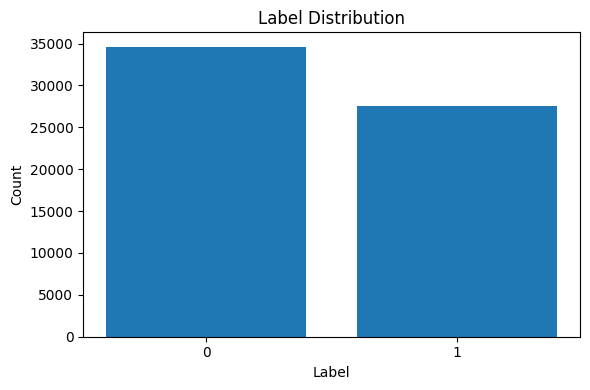

In [156]:
counts = df["label"].value_counts().sort_index()

plt.figure(figsize = (6, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Label Distribution")
plt.tight_layout()
plt.show()

---

# Length analysis

In [157]:
token_re = re.compile(r"[A-Za-z']+")
def tokenize(string: str):
    return token_re.findall(str(string).lower())

In [158]:
words_series = df["text"].apply(tokenize)
word_counts = words_series.apply(len)
labels = sorted(df["label"].dropna().unique())

## Article length

### Histogram

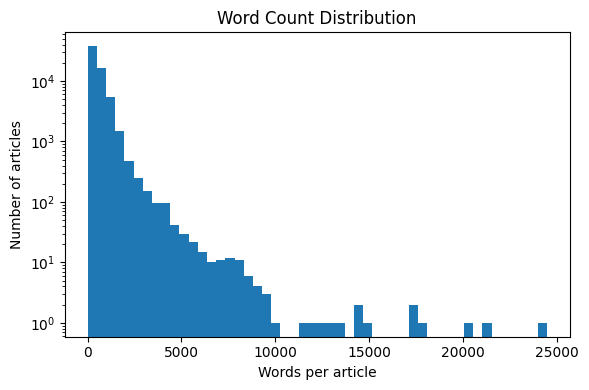

In [159]:
plt.figure(figsize = (6, 4))
plt.hist(word_counts, bins = 50)
plt.yscale("log")
plt.xlabel("Words per article")
plt.ylabel("Number of articles")
plt.title("Word Count Distribution")
plt.tight_layout()
plt.show()

### Linear violin plot

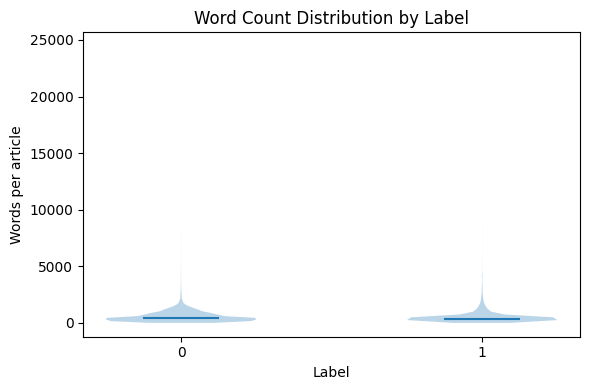

In [160]:
data_by_label = [word_counts[df["label"] == label].values for label in labels]

plt.figure(figsize = (6, 4))

parts = plt.violinplot(
    data_by_label,
    showmeans = False,
    showmedians = True,
    showextrema = False
)

plt.xticks(
    ticks = np.arange(1, len(labels) + 1),
    labels = [str(label) for label in labels]
)

plt.yscale("linear")
plt.xlabel("Label")
plt.ylabel("Words per article")
plt.title("Word Count Distribution by Label")
plt.tight_layout()
plt.show()

### Log-scale violin plot

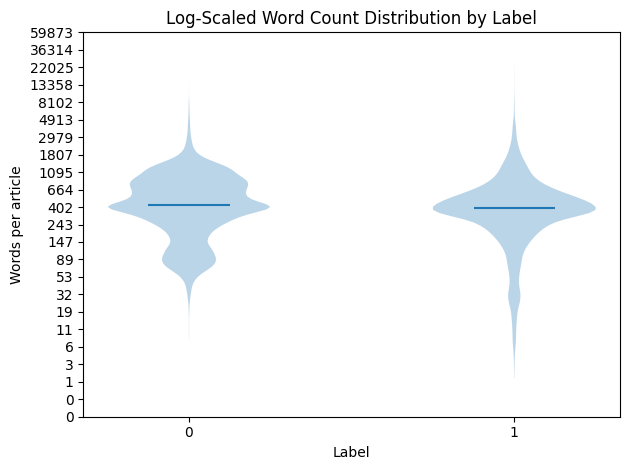

In [161]:
log_data_by_label = [np.log1p(word_counts[df["label"] == label].values) for label in labels]

parts = plt.violinplot(
    log_data_by_label,
    showmeans = False,
    showmedians = True,
    showextrema = False
)

plt.xticks(
    ticks = np.arange(1, len(labels) + 1),
    labels = [str(label) for label in labels]
)

ticks = np.arange(0, max([max(d) for d in log_data_by_label]) + 1, 0.5)

plt.yticks(
    ticks = ticks,
    labels = np.int64(np.expm1(ticks))
)

plt.xlabel("Label")
plt.ylabel("Words per article")
plt.title("Log-Scaled Word Count Distribution by Label")
plt.tight_layout()
plt.show()

### Box plot

/var/folders/4k/_p4tx7yn7q9_rv4v_xv8dlj80000gn/T/ipykernel_88139/3891823395.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_label, labels = [str(label) for label in labels], showfliers = False)


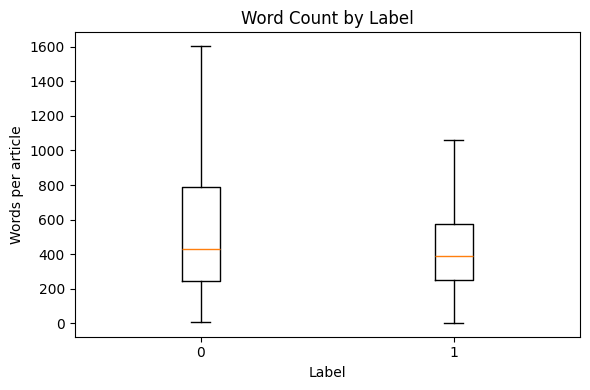

In [162]:
data_by_label = [word_counts[df["label"] == label] for label in labels]

plt.figure(figsize = (6, 4))
plt.boxplot(data_by_label, labels = [str(label) for label in labels], showfliers = False)
plt.xlabel("Label")
plt.ylabel("Words per article")
plt.title("Word Count by Label")
plt.tight_layout()
plt.show()

## URL count

In [163]:
url_counts = df["text"].apply(lambda text: len(re.findall(r"http\S+", text)))
url_counts.describe()

count    62181.000000
mean         0.099934
std          0.626926
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         31.000000
Name: text, dtype: float64

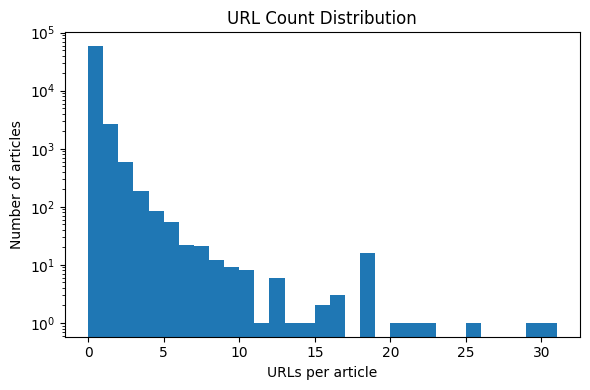

In [164]:
plt.figure(figsize = (6, 4))
plt.hist(url_counts, bins = url_counts.max())
plt.yscale("log")
plt.xlabel("URLs per article")
plt.ylabel("Number of articles")
plt.title("URL Count Distribution")
plt.tight_layout()
plt.show()

/var/folders/4k/_p4tx7yn7q9_rv4v_xv8dlj80000gn/T/ipykernel_88139/2903914826.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(url_counts_by_label, labels = [str(label) for label in labels], showfliers = False)


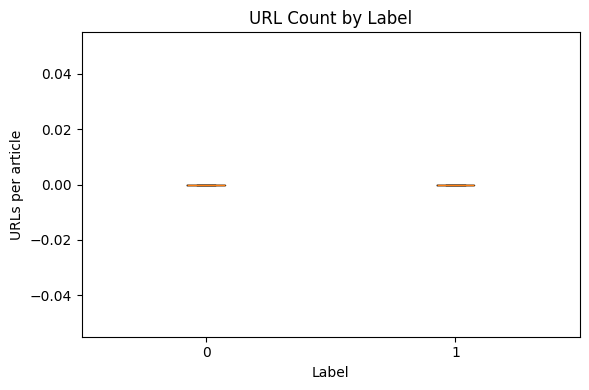

In [165]:
url_counts_by_label = [url_counts[df["label"] == label] for label in labels]

plt.figure(figsize = (6, 4))
plt.boxplot(url_counts_by_label, labels = [str(label) for label in labels], showfliers = False)
plt.xlabel("Label")
plt.ylabel("URLs per article")
plt.title("URL Count by Label")
plt.tight_layout()
plt.show()

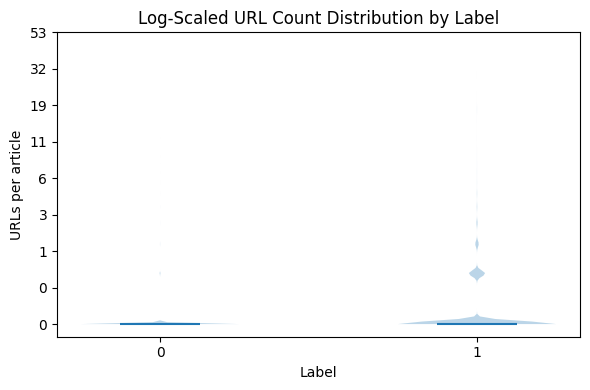

In [166]:
log_url_counts_by_label = [np.log1p(url_counts[df["label"] == label].values) for label in labels]

plt.figure(figsize = (6, 4))

parts = plt.violinplot(
    log_url_counts_by_label,
    showmeans = False,
    showmedians = True,
    showextrema = False
)

plt.xticks(
    ticks = np.arange(1, len(labels) + 1),
    labels = [str(label) for label in labels]
)

ticks = np.arange(0, max([max(d) for d in log_url_counts_by_label]) + 1, 0.5)

plt.yticks(
    ticks = ticks,
    labels = np.int64(np.expm1(ticks))
)

plt.xlabel("Label")
plt.ylabel("URLs per article")
plt.title("Log-Scaled URL Count Distribution by Label")
plt.tight_layout()
plt.show()

## Average lengths

### Average sentence length

In [167]:
sentences_series = df["text"].apply(sent_tokenize)

In [168]:
sentences_tokens_series = df["text"].apply(
    lambda text: [tokenize(sentence) for sentence in sent_tokenize(text)]
)

In [169]:
sentence_word_counts = sentences_tokens_series.apply(
    lambda text: [len(sentence) for sentence in text]
)

In [170]:
average_sentence_lengths = sentence_word_counts.apply(np.mean)

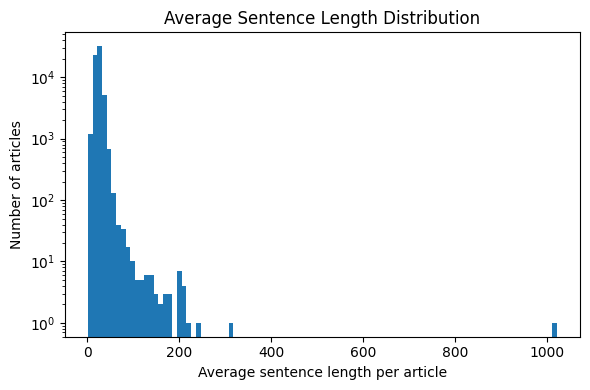

In [171]:
plt.figure(figsize = (6, 4))
plt.hist(average_sentence_lengths, bins = 100)
plt.yscale("log")
plt.xlabel("Average sentence length per article")
plt.ylabel("Number of articles")
plt.title("Average Sentence Length Distribution")
plt.tight_layout()
plt.show()

/var/folders/4k/_p4tx7yn7q9_rv4v_xv8dlj80000gn/T/ipykernel_88139/1310788247.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(average_sentence_lengths_by_label, labels = [str(label) for label in labels], showfliers = False)


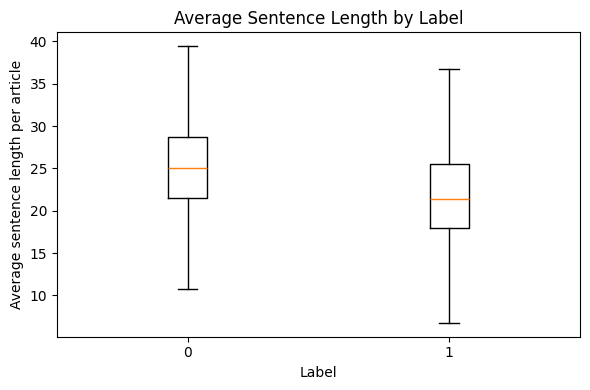

In [172]:
average_sentence_lengths_by_label = [average_sentence_lengths[df["label"] == label] for label in labels]

plt.figure(figsize = (6, 4))
plt.boxplot(average_sentence_lengths_by_label, labels = [str(label) for label in labels], showfliers = False)
plt.xlabel("Label")
plt.ylabel("Average sentence length per article")
plt.title("Average Sentence Length by Label")
plt.tight_layout()
plt.show()

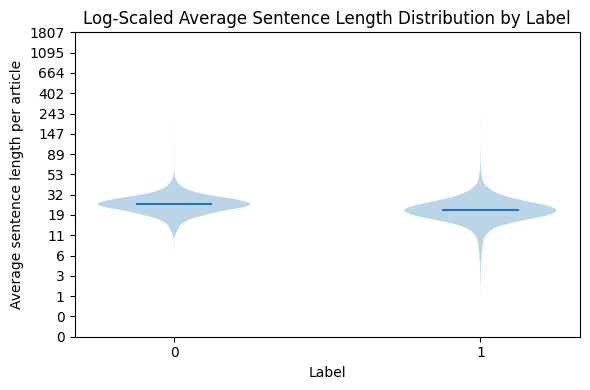

In [173]:
log_average_sentence_lengths_by_label = [np.log1p(average_sentence_lengths[df["label"] == label].values) for label in labels]

plt.figure(figsize = (6, 4))

parts = plt.violinplot(
    log_average_sentence_lengths_by_label,
    showmeans = False,
    showmedians = True,
    showextrema = False
)

plt.xticks(
    ticks = np.arange(1, len(labels) + 1),
    labels = [str(label) for label in labels]
)

ticks = np.arange(0, max([max(d) for d in log_average_sentence_lengths_by_label]) + 1, 0.5)

plt.yticks(
    ticks = ticks,
    labels = np.int64(np.expm1(ticks))
)

plt.xlabel("Label")
plt.ylabel("Average sentence length per article")
plt.title("Log-Scaled Average Sentence Length Distribution by Label")
plt.tight_layout()
plt.show()

### Average word length

In [174]:
word_lengths_series = words_series.apply(
    lambda text: [len(word) for word in text]
)

In [175]:
average_word_lengths = word_lengths_series.apply(np.mean)

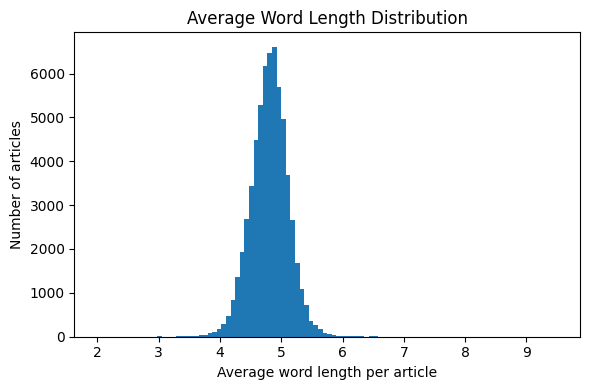

In [176]:
plt.figure(figsize = (6, 4))
plt.hist(average_word_lengths, bins = 100)
plt.yscale("linear")
plt.xlabel("Average word length per article")
plt.ylabel("Number of articles")
plt.title("Average Word Length Distribution")
plt.tight_layout()
plt.show()

/var/folders/4k/_p4tx7yn7q9_rv4v_xv8dlj80000gn/T/ipykernel_88139/1440881702.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(average_word_lengths_by_label, labels = [str(label) for label in labels], showfliers = False)


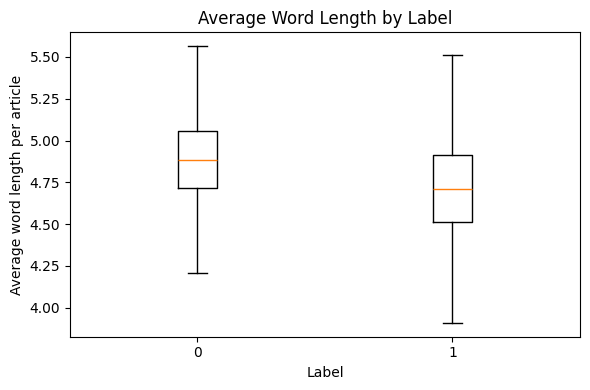

In [177]:
average_word_lengths_by_label = [average_word_lengths[df["label"] == label] for label in labels]

plt.figure(figsize = (6, 4))
plt.boxplot(average_word_lengths_by_label, labels = [str(label) for label in labels], showfliers = False)
plt.xlabel("Label")
plt.ylabel("Average word length per article")
plt.title("Average Word Length by Label")
plt.tight_layout()
plt.show()

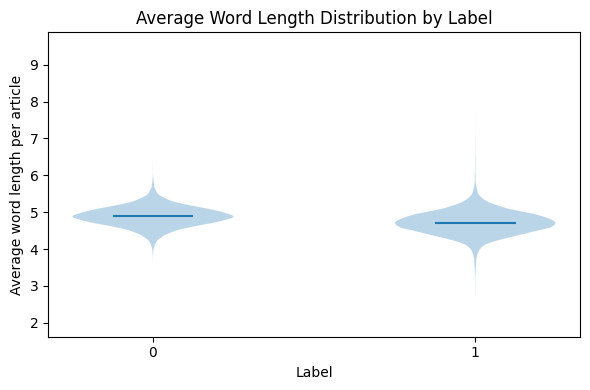

In [178]:
average_word_lengths_label = [average_word_lengths[df["label"] == label].values for label in labels]

plt.figure(figsize = (6, 4))

parts = plt.violinplot(
    average_word_lengths_by_label,
    showmeans = False,
    showmedians = True,
    showextrema = False
)

plt.xticks(
    ticks = np.arange(1, len(labels) + 1),
    labels = [str(label) for label in labels]
)

plt.yscale("linear")
plt.xlabel("Label")
plt.ylabel("Average word length per article")
plt.title("Average Word Length Distribution by Label")
plt.tight_layout()
plt.show()

---

# Frequency analysis

## Top words

In [179]:
def plot_top_elements(elements: list, title: str, top_n: int = 25):
    counter = Counter()
    for tokens in elements:
        counter.update(tokens)
    top = counter.most_common(top_n)
    words = [word for word, _ in top]
    freqs = [count for _, count in top]

    plt.figure(figsize = (6, 4))
    plt.barh(words[::-1], freqs[::-1])  # reverse so biggest is at top
    plt.xlabel("Frequency")
    plt.title(title)
    plt.tight_layout()
    plt.show()

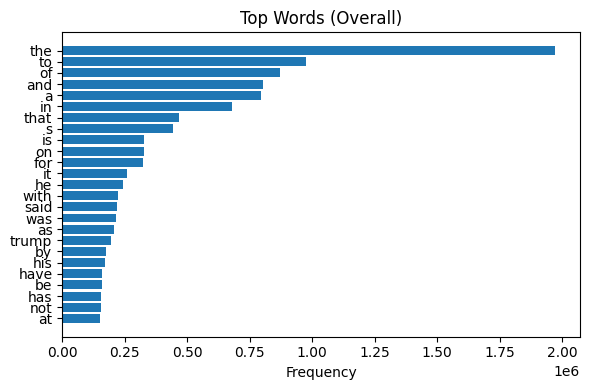

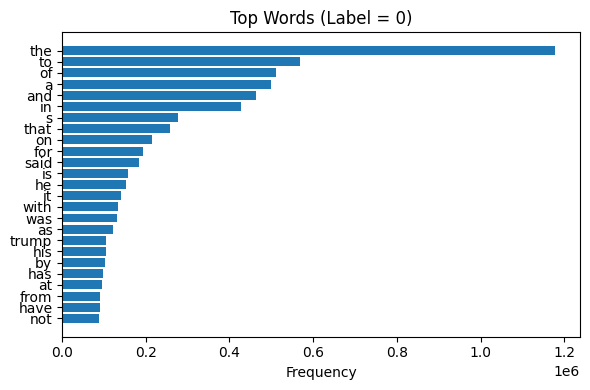

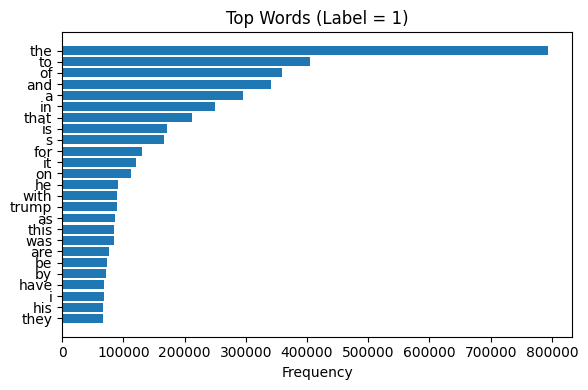

In [180]:
plot_top_elements(words_series, "Top Words (Overall)", top_n = 25)

for label in labels:
    plot_top_elements(words_series[df["label"] == label], f"Top Words (Label = {label})", top_n = 25)

## Top 3-grams

In [181]:
ngrams3_series = words_series.apply(lambda s: [str(ngram) for ngram in list(ngrams(s, 3))])

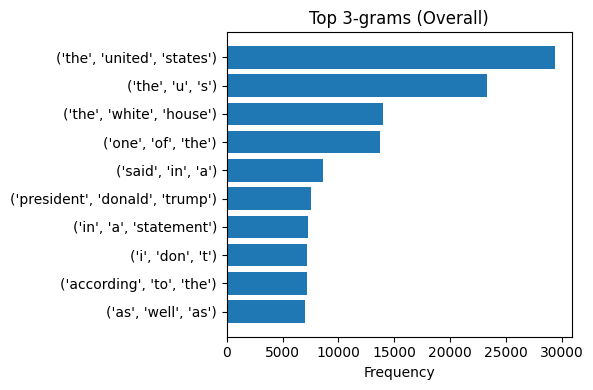

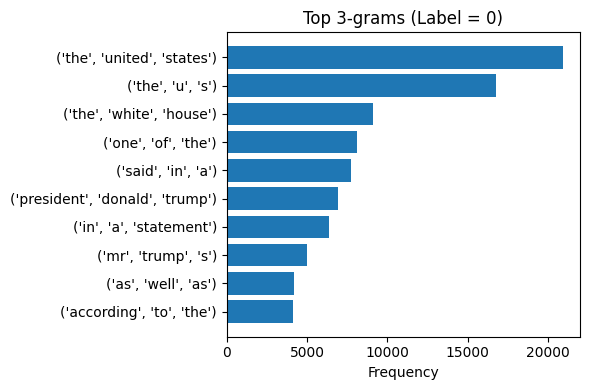

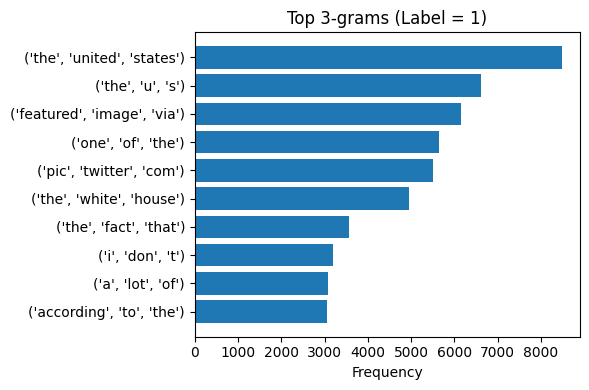

In [182]:
plot_top_elements(ngrams3_series, "Top 3-grams (Overall)", top_n = 10)
for label in labels:
    plot_top_elements(ngrams3_series[df["label"] == label], f"Top 3-grams (Label = {label})", top_n = 10)

## Top websites

In [183]:
urls_series = df["text"].apply(
    lambda text: re.findall(r"https?:\/\/([^\/\s]+)", text)
)

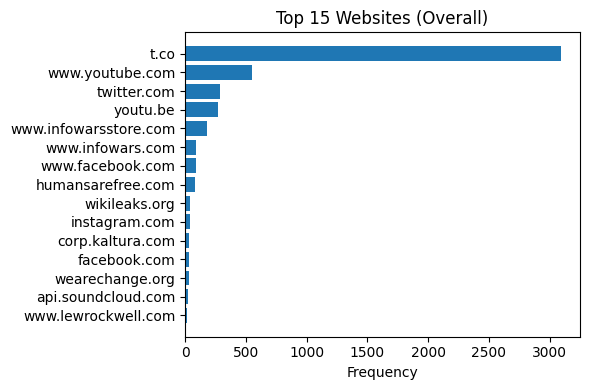

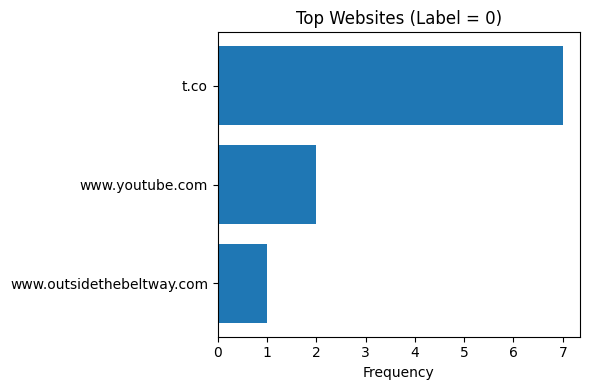

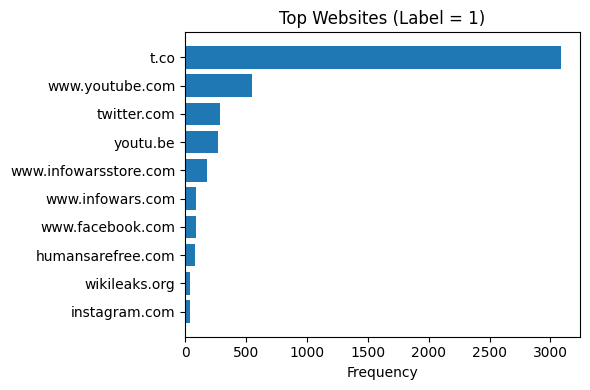

In [184]:
plot_top_elements(urls_series, "Top 15 Websites (Overall)", 15)
for label in labels:
    plot_top_elements(urls_series[df["label"] == label], f"Top Websites (Label = {label})", top_n = 10)

Remove URLs.

In [185]:
#df["text"].apply(lambda text: re.sub(r"http\S+", "<URL>", text))